# P05 European Climate Trends
## Notebook 03 — Visualisation

**Project:** P05 European Climate Trends  
**Author:** Ose Omokhua  

---

## Purpose

This notebook produces five production-grade figures at 300 DPI for P05.
Each figure is designed to communicate one key finding to a non-technical
policy audience - a Head of Data at DESNZ, the Met Office, or a European
climate agency.

The five figures are:

1. **Pan-European warming rates** - horizontal bar chart of Sen's slope
   per decade for all 30 countries, ordered by warming rate
2. **Temperature anomaly time series** - multi-country line chart of
   annual temperature anomalies relative to 1991-2020, highlighting the
   post-2000 acceleration
3. **North-south precipitation divide** - diverging bar chart of
   precipitation Sen's slope per decade, separating significant from
   non-significant trends
4. **Warming rate vs latitude** - scatter plot showing the relationship
   between country centroid latitude and warming rate, with regression line
5. **Recent decade anomaly map** - ranked bar chart of mean temperature
   anomaly for 2015-2024 by country, showing which countries have warmed
   most above their own baseline in the most recent decade

All figures are saved to `figures/` at 300 DPI.

## 1. Environment Setup

We import all required libraries, load the project configuration, and
read all processed data files produced in notebooks 01 and 02. No
computation is performed in this notebook - all analytical results are
loaded from `data/processed/` and rendered as figures.

In [1]:
import os
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sys.path.insert(0, os.path.abspath(".."))
import config
importlib.reload(config)

# -- Plot style ---------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       config.FIGURE_DPI,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

# -- Load processed data ------------------------------------------------------
tg_annual_df   = pd.read_csv(os.path.join(config.DATA_PROCESSED, "tg_annual.csv"))
rr_annual_df   = pd.read_csv(os.path.join(config.DATA_PROCESSED, "rr_annual.csv"))
tg_anomaly_df  = pd.read_csv(os.path.join(config.DATA_PROCESSED, "tg_anomaly.csv"))
rr_anomaly_df  = pd.read_csv(os.path.join(config.DATA_PROCESSED, "rr_anomaly.csv"))
trends_df      = pd.read_csv(os.path.join(config.DATA_PROCESSED, "trends_final.csv"))

print("Data loaded successfully.")
print(f"  tg_annual_df  : {tg_annual_df.shape}")
print(f"  rr_annual_df  : {rr_annual_df.shape}")
print(f"  tg_anomaly_df : {tg_anomaly_df.shape}")
print(f"  rr_anomaly_df : {rr_anomaly_df.shape}")
print(f"  trends_df     : {trends_df.shape}")
print()
print("Figures directory:", config.FIGURES_DIR)
print("Figure DPI       :", config.FIGURE_DPI)

Data loaded successfully.
  tg_annual_df  : (2250, 3)
  rr_annual_df  : (2250, 3)
  tg_anomaly_df : (2250, 3)
  rr_anomaly_df : (2250, 3)
  trends_df     : (60, 15)

Figures directory: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project5\figures
Figure DPI       : 300


## Figure 1 -- Pan-European Warming Rates

A horizontal bar chart showing Sen's slope per decade for all 30 countries,
ordered from fastest to slowest warming. Sen's slope is used rather than
OLS slope because it is the robust estimator - resistant to outlier years.

Design decisions:

- Horizontal bars because country names are long and read naturally on the
  y-axis
- Ordered by warming rate so the reader immediately sees the gradient from
  Baltic states to Mediterranean
- Bars coloured by warming rate using a sequential red palette - darker
  red for faster warming - to reinforce the magnitude message visually
- Error bars showing the OLS 95% confidence interval to communicate
  uncertainty honestly
- A vertical reference line at zero to make it unambiguous that all
  trends are positive
- Significant trends marked with a filled bar; non-significant with a
  hatched bar - though for temperature all 30 are significant so all
  bars are filled

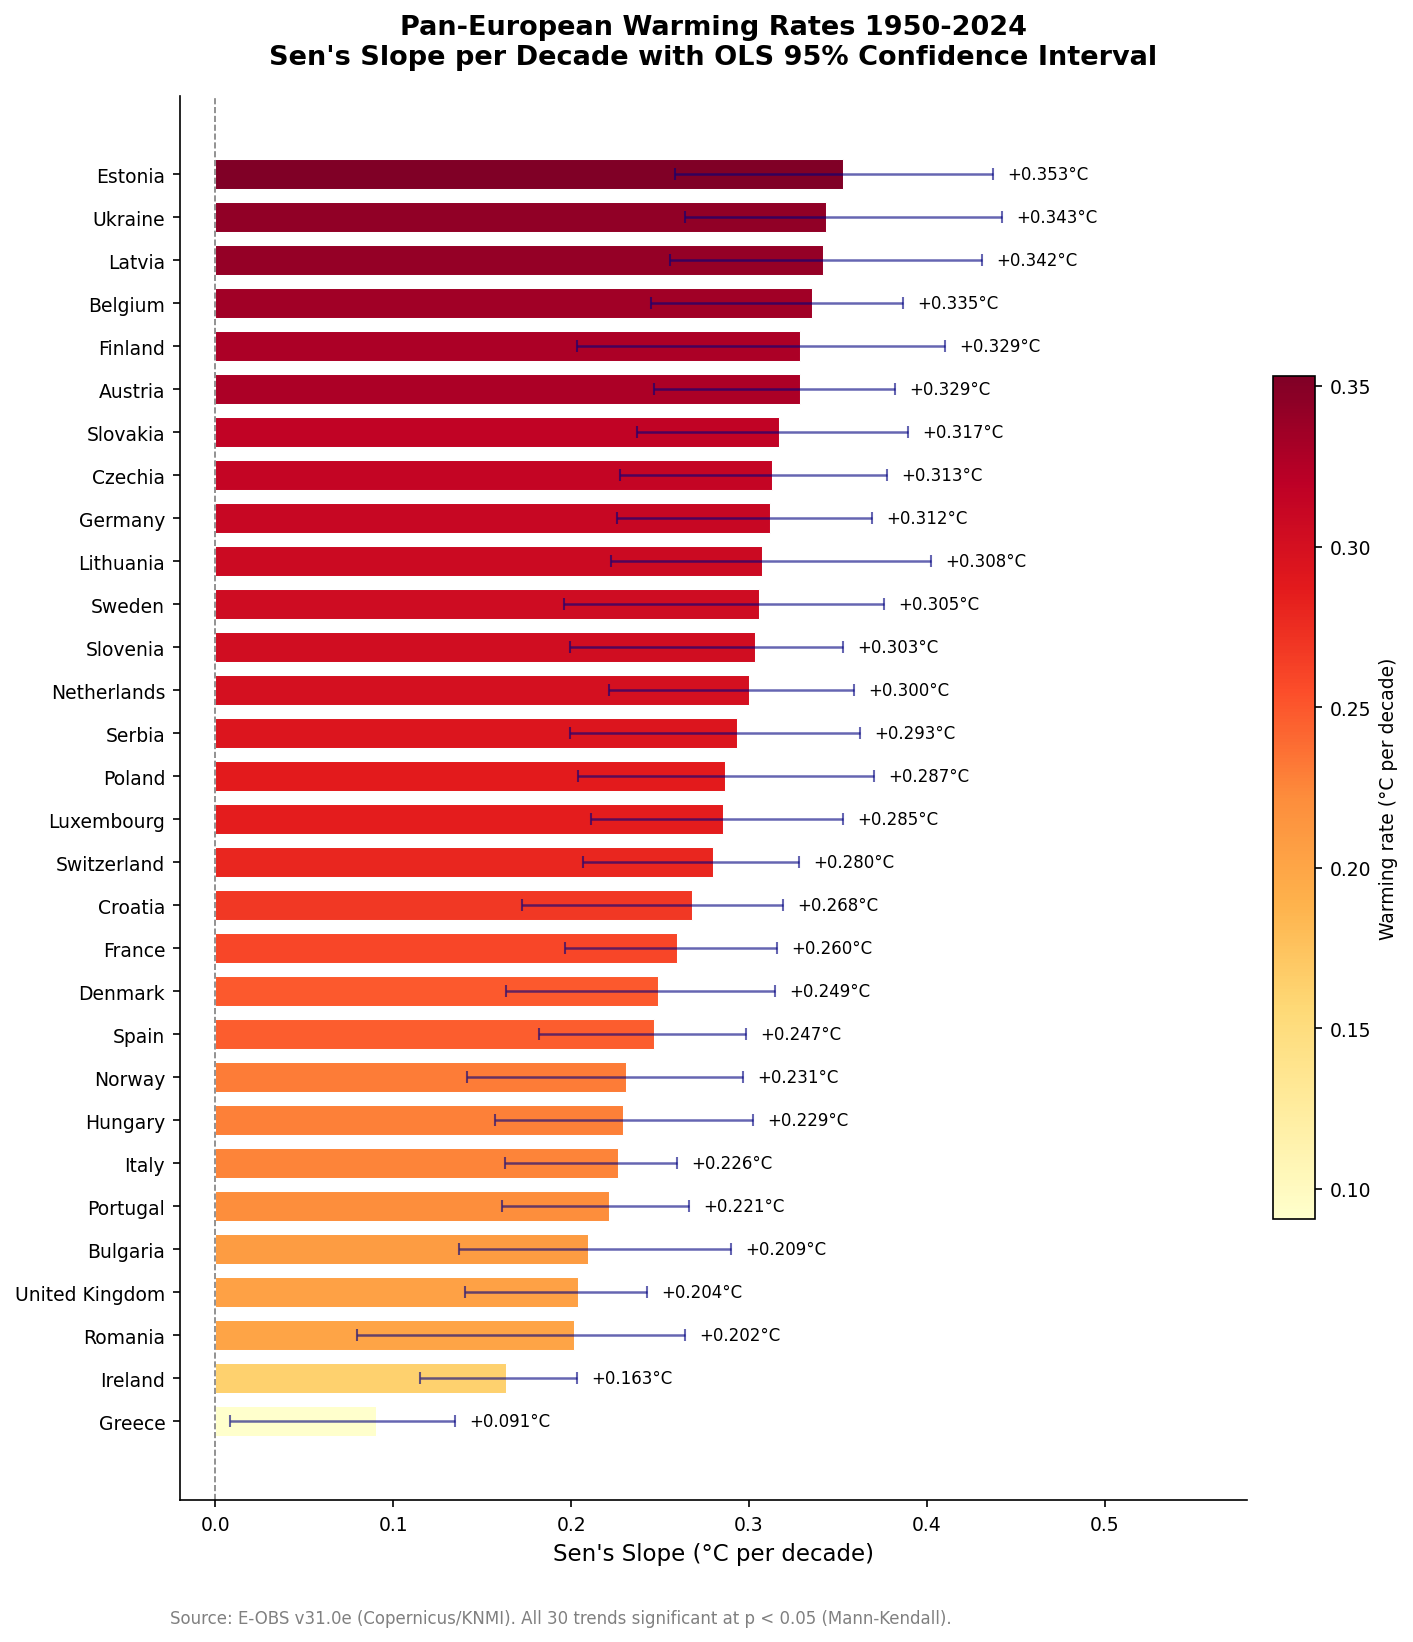

Figure 1 saved to: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project5\figures\01_pan_european_warming_rates.png


In [3]:
tg_trends = trends_df[trends_df["variable"] == "temperature"].copy()
tg_trends = tg_trends.sort_values("sens_decade", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 11))

# -- Colour mapping -----------------------------------------------------------
norm   = plt.Normalize(tg_trends["sens_decade"].min(), tg_trends["sens_decade"].max())
cmap   = plt.cm.YlOrRd
colors = [cmap(norm(v)) for v in tg_trends["sens_decade"]]

# -- Bars ---------------------------------------------------------------------
bars = ax.barh(
    tg_trends["country"],
    tg_trends["sens_decade"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

# -- Error bars (OLS 95% CI) --------------------------------------------------
ax.errorbar(
    tg_trends["ols_slope_decade"],
    tg_trends["country"],
    xerr=[
        tg_trends["ols_slope_decade"] - tg_trends["ols_ci_lower"],
        tg_trends["ols_ci_upper"] - tg_trends["ols_slope_decade"],
    ],
    fmt="none",
    color="navy",
    alpha=0.6,
    linewidth=1.2,
    capsize=3,
)

# -- Reference line at zero ---------------------------------------------------
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# -- Value labels -------------------------------------------------------------
for i, (_, row) in enumerate(tg_trends.iterrows()):
    ax.text(
        row["ols_ci_upper"] + 0.008,
        i,
        f"+{row['sens_decade']:.3f}°C",
        va="center",
        ha="left",
        fontsize=8,
        color="black",
    )

# -- Colourbar ----------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Warming rate (°C per decade)", fontsize=9)

# -- Labels and title ---------------------------------------------------------
ax.set_xlabel("Sen's Slope (°C per decade)", fontsize=11)
ax.set_title(
    "Pan-European Warming Rates 1950-2024\n"
    "Sen's Slope per Decade with OLS 95% Confidence Interval",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(-0.02, 0.58)

# -- Footnote -----------------------------------------------------------------
fig.text(
    0.12, 0.01,
    "Source: E-OBS v31.0e (Copernicus/KNMI). All 30 trends significant at p < 0.05 (Mann-Kendall).",
    fontsize=8, color="grey"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# -- Save ---------------------------------------------------------------------
fig1_path = os.path.join(config.FIGURES_DIR, "01_pan_european_warming_rates.png")
fig.savefig(fig1_path, dpi=config.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure 1 saved to: {fig1_path}")

## Figure 2 -- Temperature Anomaly Time Series

A multi-country line chart showing annual temperature anomalies relative
to the 1991-2020 WMO reference period for selected countries representing
different European climate zones.

We select six representative countries covering the full range of warming
rates and climate zones:

- Estonia - fastest warming, Baltic
- United Kingdom - slower warming, Atlantic
- Germany - central European continental
- Spain - Mediterranean south
- Norway - Nordic Atlantic
- Greece - slowest warming, Mediterranean east

Design decisions:

- Anomaly rather than absolute temperature so all six countries are on a
  comparable scale regardless of their baseline climate
- A smoothed trend line (10-year rolling mean) overlaid on the raw annual
  values to show the long-term signal through interannual noise
- A horizontal reference line at zero marking the 1991-2020 baseline
- A shaded band highlighting the reference period 1991-2020
- A shaded band highlighting the most recent decade 2015-2024
- Distinct colours per country using a qualitative palette

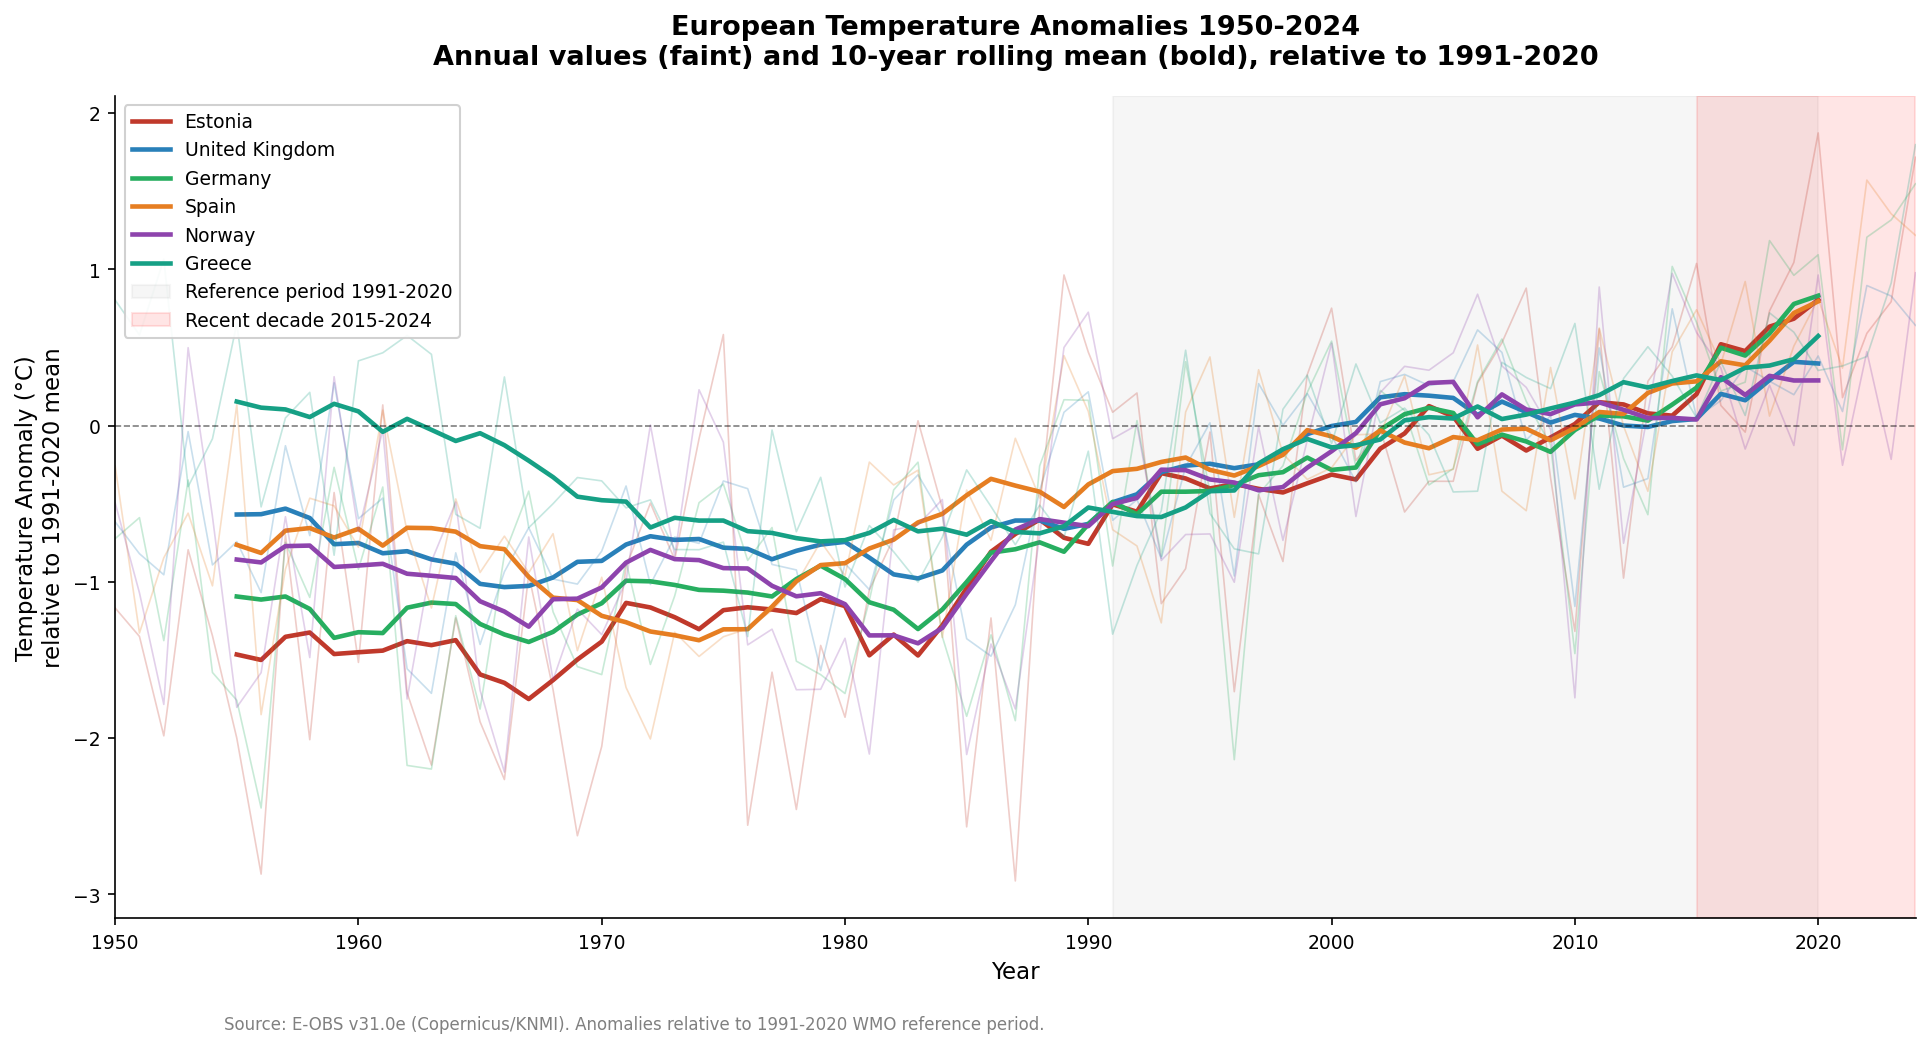

Figure 2 saved to: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project5\figures\02_temperature_anomaly_timeseries.png


In [4]:
selected_countries = ["Estonia", "United Kingdom", "Germany", "Spain", "Norway", "Greece"]
palette = ["#c0392b", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]

fig, ax = plt.subplots(figsize=(13, 7))

for country, color in zip(selected_countries, palette):
    country_data = tg_anomaly_df[tg_anomaly_df["country"] == country].set_index("year")
    anomaly = country_data["tg_anomaly_c"]

    # Raw annual anomaly -- thin, semi-transparent
    ax.plot(
        anomaly.index, anomaly.values,
        color=color, alpha=0.25, linewidth=0.8
    )

    # 10-year rolling mean -- bold
    rolling = anomaly.rolling(window=10, center=True).mean()
    ax.plot(
        rolling.index, rolling.values,
        color=color, linewidth=2.2, label=country
    )

# -- Reference period shading -------------------------------------------------
ax.axvspan(
    config.REFERENCE_PERIOD_START, config.REFERENCE_PERIOD_END,
    alpha=0.07, color="grey", label="Reference period 1991-2020"
)

# -- Recent decade shading ----------------------------------------------------
ax.axvspan(
    2015, 2024,
    alpha=0.10, color="red", label="Recent decade 2015-2024"
)

# -- Zero reference line ------------------------------------------------------
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# -- Labels and title ---------------------------------------------------------
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Temperature Anomaly (°C)\nrelative to 1991-2020 mean", fontsize=11)
ax.set_title(
    "European Temperature Anomalies 1950-2024\n"
    "Annual values (faint) and 10-year rolling mean (bold), relative to 1991-2020",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(1950, 2024)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

# -- Footnote -----------------------------------------------------------------
fig.text(
    0.12, 0.01,
    "Source: E-OBS v31.0e (Copernicus/KNMI). Anomalies relative to 1991-2020 WMO reference period.",
    fontsize=8, color="grey"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# -- Save ---------------------------------------------------------------------
fig2_path = os.path.join(config.FIGURES_DIR, "02_temperature_anomaly_timeseries.png")
fig.savefig(fig2_path, dpi=config.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure 2 saved to: {fig2_path}")

## Figure 3 -- North-South Precipitation Divide

A diverging horizontal bar chart showing precipitation Sen's slope per
decade for all 30 countries, ordered from wettest trend to driest trend.
Bars are coloured by direction and significance:

- Dark blue - significant wetting trend
- Light blue - non-significant wetting trend
- Light red - non-significant drying trend
- Dark red - significant drying trend

This four-colour scheme communicates two dimensions simultaneously -
direction and statistical confidence - without requiring the reader to
cross-reference a separate significance table.

A vertical reference line at zero separates the wetting countries on the
right from the drying countries on the left. Country names are placed on
the y-axis. The chart is designed to be read as a policy document figure
- a minister or senior analyst should be able to identify the key message
(northern Europe wetting, Mediterranean drying) in under five seconds.

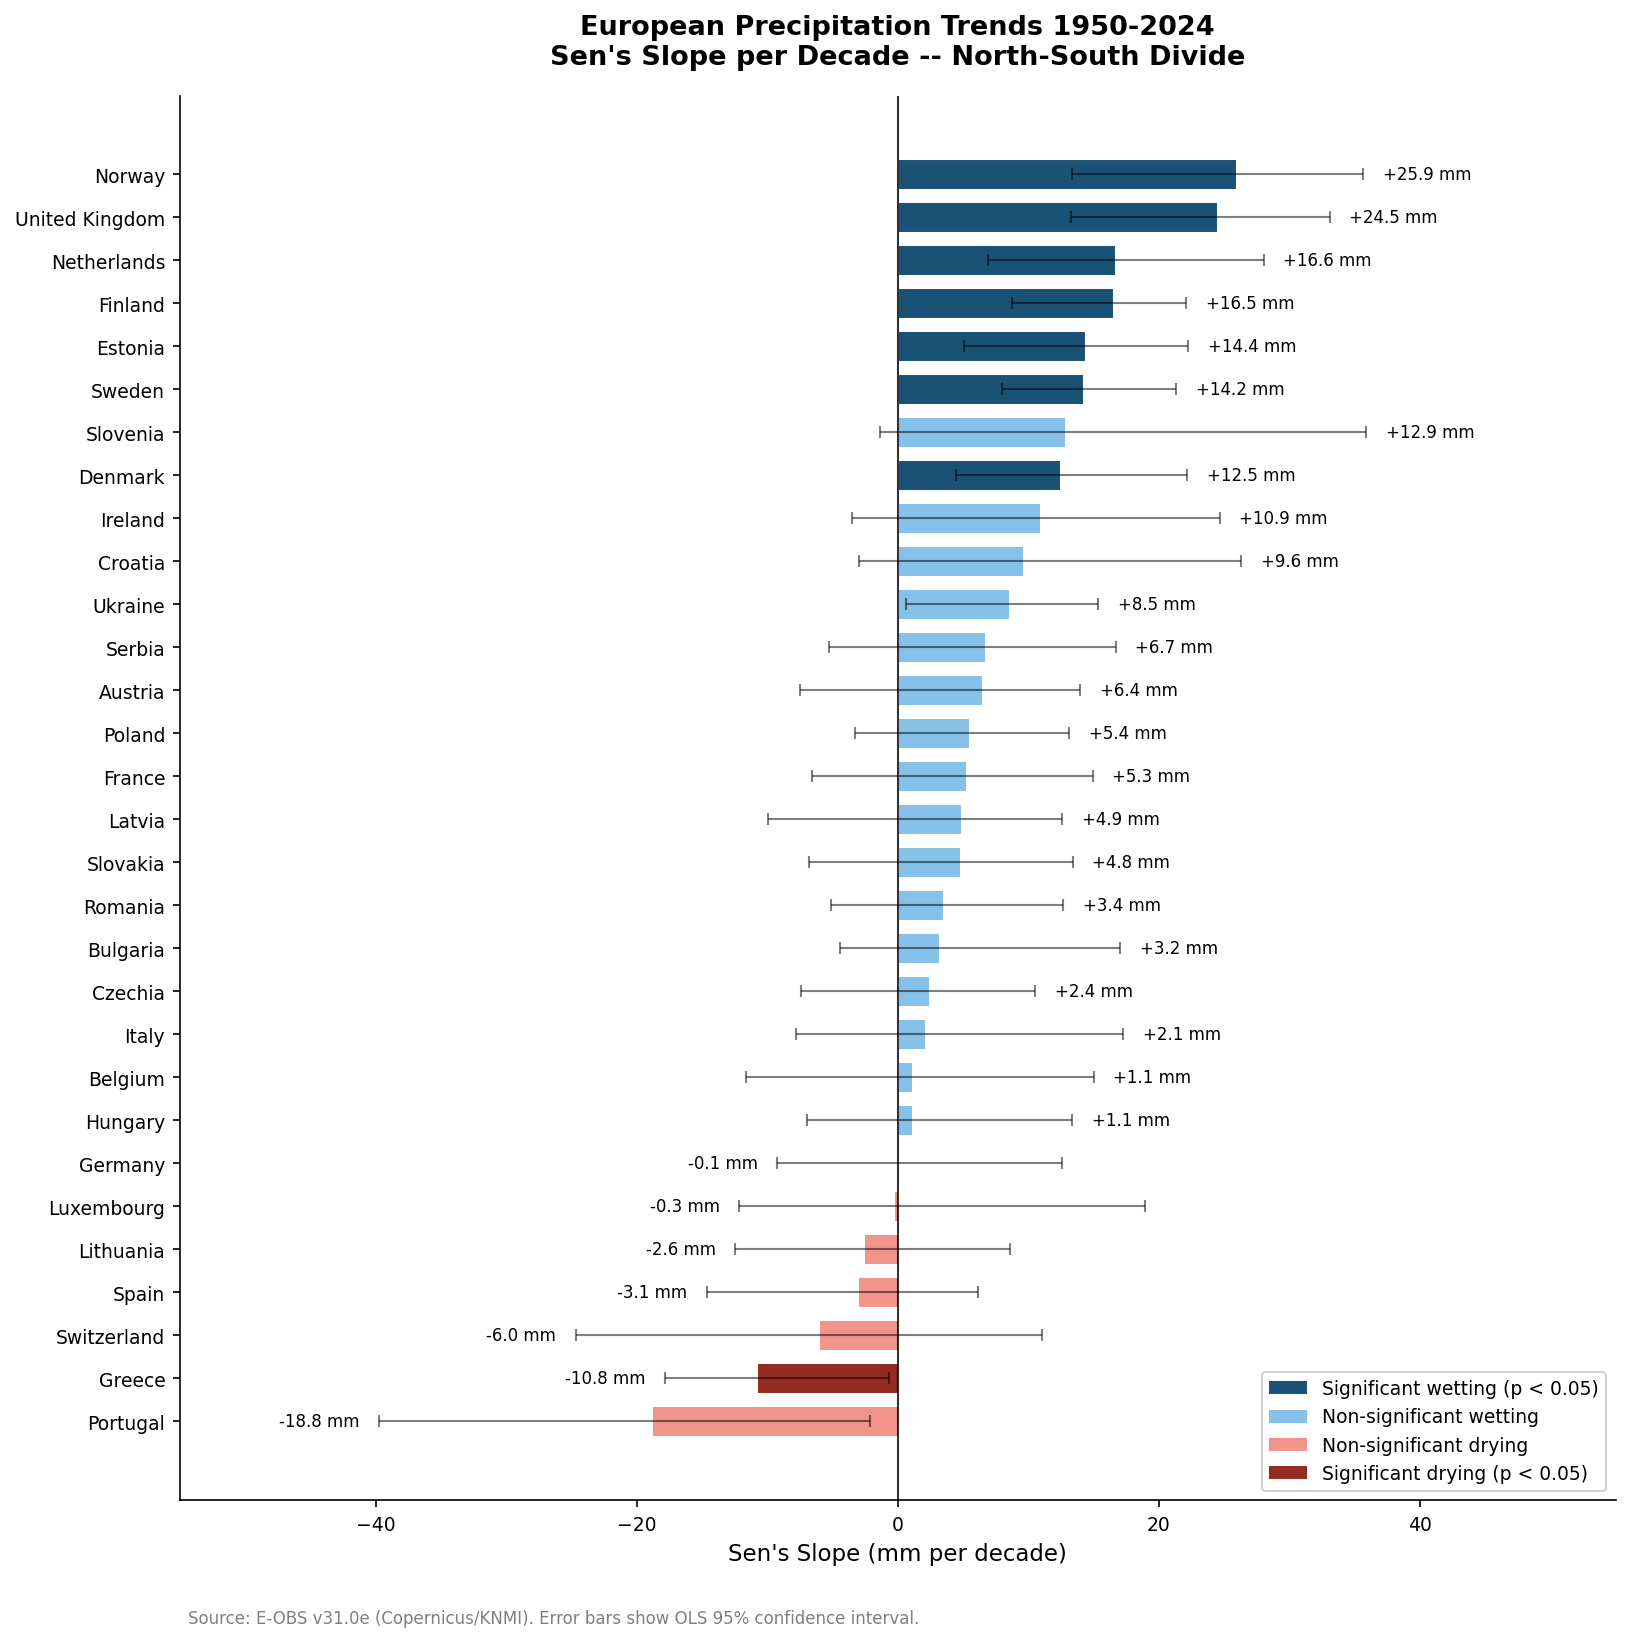

Figure 3 saved to: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project5\figures\03_precipitation_north_south_divide.png


In [5]:
rr_trends = trends_df[trends_df["variable"] == "precipitation"].copy()
rr_trends = rr_trends.sort_values("sens_decade", ascending=True).reset_index(drop=True)

# -- Colour assignment --------------------------------------------------------
def bar_color(row):
    if row["significant"] and row["sens_decade"] > 0:
        return "#1a5276"   # dark blue -- significant wetting
    elif not row["significant"] and row["sens_decade"] > 0:
        return "#85c1e9"   # light blue -- non-significant wetting
    elif not row["significant"] and row["sens_decade"] <= 0:
        return "#f1948a"   # light red -- non-significant drying
    else:
        return "#922b21"   # dark red -- significant drying

rr_trends["bar_color"] = rr_trends.apply(bar_color, axis=1)

fig, ax = plt.subplots(figsize=(11, 11))

# -- Bars ---------------------------------------------------------------------
bars = ax.barh(
    rr_trends["country"],
    rr_trends["sens_decade"],
    color=rr_trends["bar_color"],
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

# -- Error bars (OLS 95% CI) --------------------------------------------------
ax.errorbar(
    rr_trends["ols_slope_decade"],
    rr_trends["country"],
    xerr=[
        rr_trends["ols_slope_decade"] - rr_trends["ols_ci_lower"],
        rr_trends["ols_ci_upper"] - rr_trends["ols_slope_decade"],
    ],
    fmt="none",
    color="black",
    alpha=0.5,
    linewidth=1.0,
    capsize=3,
)

# -- Reference line at zero ---------------------------------------------------
ax.axvline(0, color="black", linewidth=1.0, linestyle="-", alpha=0.8)

# -- Value labels -------------------------------------------------------------
for i, (_, row) in enumerate(rr_trends.iterrows()):
    ha    = "left"  if row["sens_decade"] >= 0 else "right"
    xpos  = row["ols_ci_upper"] + 1.5 if row["sens_decade"] >= 0 else row["ols_ci_lower"] - 1.5
    label = f"+{row['sens_decade']:.1f}" if row["sens_decade"] >= 0 else f"{row['sens_decade']:.1f}"
    ax.text(xpos, i, f"{label} mm", va="center", ha=ha, fontsize=8, color="black")

# -- Custom legend ------------------------------------------------------------
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1a5276", label="Significant wetting (p < 0.05)"),
    Patch(facecolor="#85c1e9", label="Non-significant wetting"),
    Patch(facecolor="#f1948a", label="Non-significant drying"),
    Patch(facecolor="#922b21", label="Significant drying (p < 0.05)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.9)

# -- Labels and title ---------------------------------------------------------
ax.set_xlabel("Sen's Slope (mm per decade)", fontsize=11)
ax.set_title(
    "European Precipitation Trends 1950-2024\n"
    "Sen's Slope per Decade -- North-South Divide",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(-55, 55)

# -- Footnote -----------------------------------------------------------------
fig.text(
    0.12, 0.01,
    "Source: E-OBS v31.0e (Copernicus/KNMI). Error bars show OLS 95% confidence interval.",
    fontsize=8, color="grey"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# -- Save ---------------------------------------------------------------------
fig3_path = os.path.join(config.FIGURES_DIR, "03_precipitation_north_south_divide.png")
fig.savefig(fig3_path, dpi=config.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure 3 saved to: {fig3_path}")

## Figure 4 -- Warming Rate vs Latitude

A scatter plot showing the relationship between each country's centroid
latitude and its temperature Sen's slope per decade. This figure tests
the hypothesis that warming rates vary systematically with latitude across
Europe.

We compute country centroid latitudes from the E-OBS mask -- the mean
latitude of all grid points inside each country boundary. This is more
accurate than using capital city coordinates because it reflects the
spatial extent of the country rather than a single point.

Design decisions:

- Each country represented as a labelled point
- Point size scaled by the number of grid points - larger countries have
  more spatial weight and their trend estimates are more spatially
  representative
- A linear regression line fitted through all 30 points with a 95%
  confidence band
- Points coloured by climate zone - Baltic, Continental, Atlantic,
  Mediterranean - to show whether the latitude relationship holds within
  as well as across climate zones
- Pearson correlation coefficient and p-value annotated on the figure

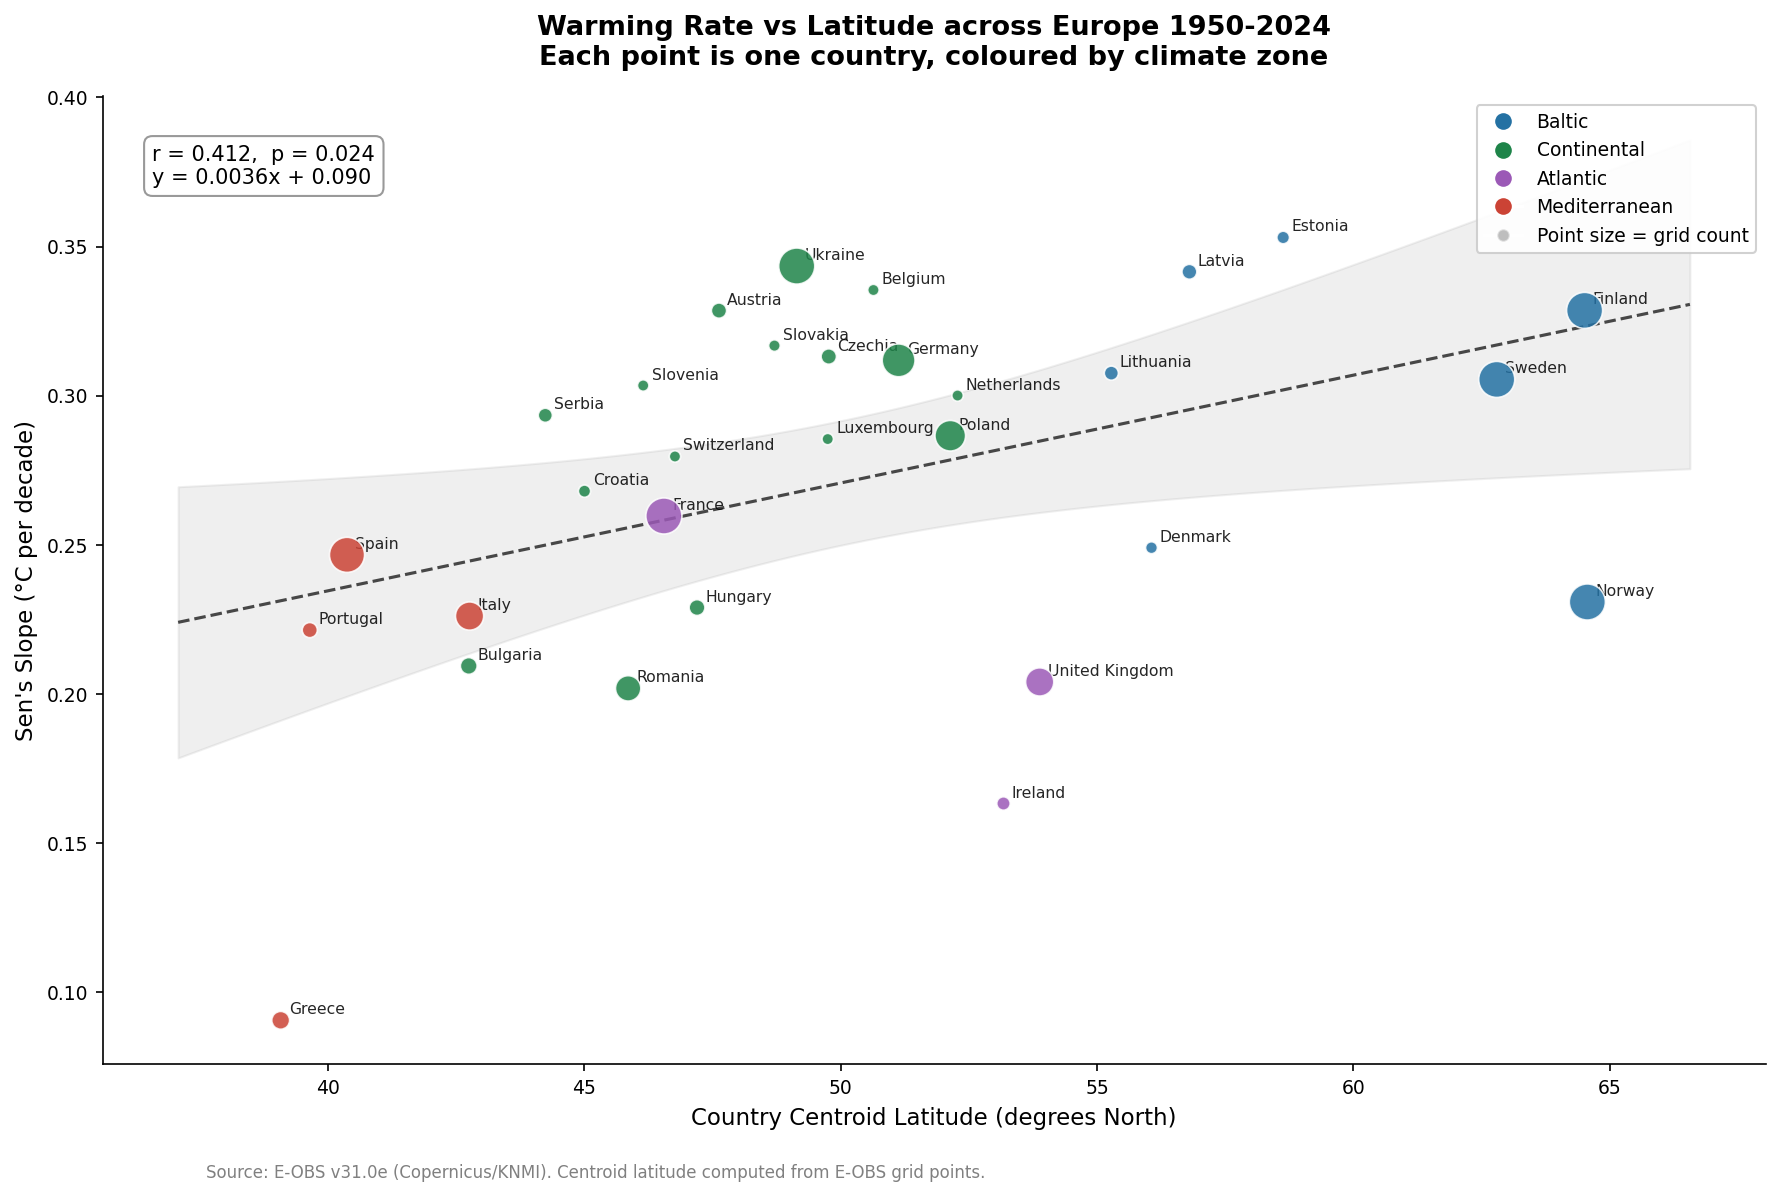

Figure 4 saved to: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project5\figures\04_warming_rate_vs_latitude.png
Pearson r = 0.412, p = 0.0239


In [6]:
import regionmask
import xarray as xr

# -- Recompute country centroids and grid counts from mask --------------------
land110 = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
name_to_number = {name: num for name, num in zip(land110.names, land110.numbers)}

ds_tg = xr.open_dataset(
    os.path.join(config.DATA_RAW, "tg_ens_mean_0.25deg_reg_v31.0e.nc"),
    engine="netcdf4"
)
lats = ds_tg.latitude.values
lons = ds_tg.longitude.values
mask = land110.mask(lons, lats)

centroid_lats  = {}
grid_counts    = {}

for country in config.COUNTRIES:
    if country not in name_to_number:
        continue
    region_number   = name_to_number[country]
    country_mask_np = (mask.values == region_number)
    lat_grid, _     = np.meshgrid(lats, lons, indexing="ij")
    centroid_lats[country]  = float(lat_grid[country_mask_np].mean())
    grid_counts[country]    = int(country_mask_np.sum())

# -- Climate zone assignment --------------------------------------------------
climate_zones = {
    "Baltic":        ["Estonia", "Latvia", "Lithuania", "Finland", "Sweden",
                      "Denmark", "Norway"],
    "Continental":   ["Germany", "Poland", "Czechia", "Slovakia", "Hungary",
                      "Austria", "Romania", "Bulgaria", "Ukraine", "Serbia",
                      "Croatia", "Slovenia", "Luxembourg", "Belgium",
                      "Netherlands", "Switzerland"],
    "Atlantic":      ["United Kingdom", "Ireland", "France"],
    "Mediterranean": ["Spain", "Portugal", "Italy", "Greece"],
}
zone_colors = {
    "Baltic":        "#2471a3",
    "Continental":   "#1e8449",
    "Atlantic":      "#9b59b6",
    "Mediterranean": "#cb4335",
}
country_zone  = {}
country_color = {}
for zone, countries in climate_zones.items():
    for c in countries:
        country_zone[c]  = zone
        country_color[c] = zone_colors[zone]

# -- Build scatter DataFrame --------------------------------------------------
tg_trends = trends_df[trends_df["variable"] == "temperature"].copy()
tg_trends["centroid_lat"] = tg_trends["country"].map(centroid_lats)
tg_trends["grid_count"]   = tg_trends["country"].map(grid_counts)
tg_trends["zone"]         = tg_trends["country"].map(country_zone)
tg_trends["color"]        = tg_trends["country"].map(country_color)

# -- Pearson correlation ------------------------------------------------------
r, p = stats.pearsonr(tg_trends["centroid_lat"], tg_trends["sens_decade"])

# -- OLS regression line ------------------------------------------------------
x    = tg_trends["centroid_lat"].values
y    = tg_trends["sens_decade"].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min() - 2, x.max() + 2, 100)
y_line = m * x_line + b

# -- 95% confidence band ------------------------------------------------------
n       = len(x)
x_mean  = x.mean()
s_err   = np.sqrt(np.sum((y - (m * x + b))**2) / (n - 2))
t_crit  = stats.t.ppf(0.975, df=n - 2)
se_line = s_err * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
ci_upper = y_line + t_crit * se_line
ci_lower = y_line - t_crit * se_line

fig, ax = plt.subplots(figsize=(12, 8))

# -- Confidence band ----------------------------------------------------------
ax.fill_between(x_line, ci_lower, ci_upper, alpha=0.12, color="grey")

# -- Regression line ----------------------------------------------------------
ax.plot(x_line, y_line, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

# -- Scatter points -----------------------------------------------------------
size_scale = [max(30, min(300, gc / 3)) for gc in tg_trends["grid_count"]]
ax.scatter(
    tg_trends["centroid_lat"],
    tg_trends["sens_decade"],
    c=tg_trends["color"],
    s=size_scale,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.8,
    zorder=5,
)

# -- Country labels -----------------------------------------------------------
for _, row in tg_trends.iterrows():
    ax.annotate(
        row["country"],
        xy=(row["centroid_lat"], row["sens_decade"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=7.5,
        color="black",
        alpha=0.85,
    )

# -- Zone legend --------------------------------------------------------------
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
           markersize=9, label=z)
    for z, c in zone_colors.items()
]
legend_elements.append(
    Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
           markersize=6, label="Point size = grid count", alpha=0.5)
)
ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

# -- Correlation annotation ---------------------------------------------------
p_str = f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
ax.annotate(
    f"r = {r:.3f},  p = {p_str}\ny = {m:.4f}x + {b:.3f}",
    xy=(0.03, 0.95), xycoords="axes fraction",
    fontsize=10, va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="grey", alpha=0.8)
)

# -- Labels and title ---------------------------------------------------------
ax.set_xlabel("Country Centroid Latitude (degrees North)", fontsize=11)
ax.set_ylabel("Sen's Slope (°C per decade)", fontsize=11)
ax.set_title(
    "Warming Rate vs Latitude across Europe 1950-2024\n"
    "Each point is one country, coloured by climate zone",
    fontsize=13, fontweight="bold", pad=15
)

# -- Footnote -----------------------------------------------------------------
fig.text(
    0.12, 0.01,
    "Source: E-OBS v31.0e (Copernicus/KNMI). Centroid latitude computed from E-OBS grid points.",
    fontsize=8, color="grey"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# -- Save ---------------------------------------------------------------------
fig4_path = os.path.join(config.FIGURES_DIR, "04_warming_rate_vs_latitude.png")
fig.savefig(fig4_path, dpi=config.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure 4 saved to: {fig4_path}")
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

## Figure 5 -- Recent Decade Anomaly Ranking

A ranked horizontal bar chart showing the mean temperature anomaly for
2015-2024 relative to the 1991-2020 WMO reference period for all 30
countries. This figure answers the most policy-relevant question in the
entire analysis: which countries have already warmed most above their own
modern baseline in the most recent decade?

This is distinct from the warming rate figure - a country can have a
fast warming rate but a modest recent anomaly if it started from a very
cold baseline, or a large recent anomaly if warming has accelerated
recently above the long-term trend.

Design decisions:

- Bars coloured by anomaly magnitude using a sequential red palette -
  all anomalies are positive so the palette runs from pale orange to
  deep red
- Countries ordered by mean 2015-2024 anomaly descending so the most
  affected countries are immediately visible at the top
- A vertical reference line at the pan-European mean anomaly to
  contextualise individual country values against the collective average
- The pan-European mean annotated with a label
- Value labels outside each bar showing the anomaly to two decimal places

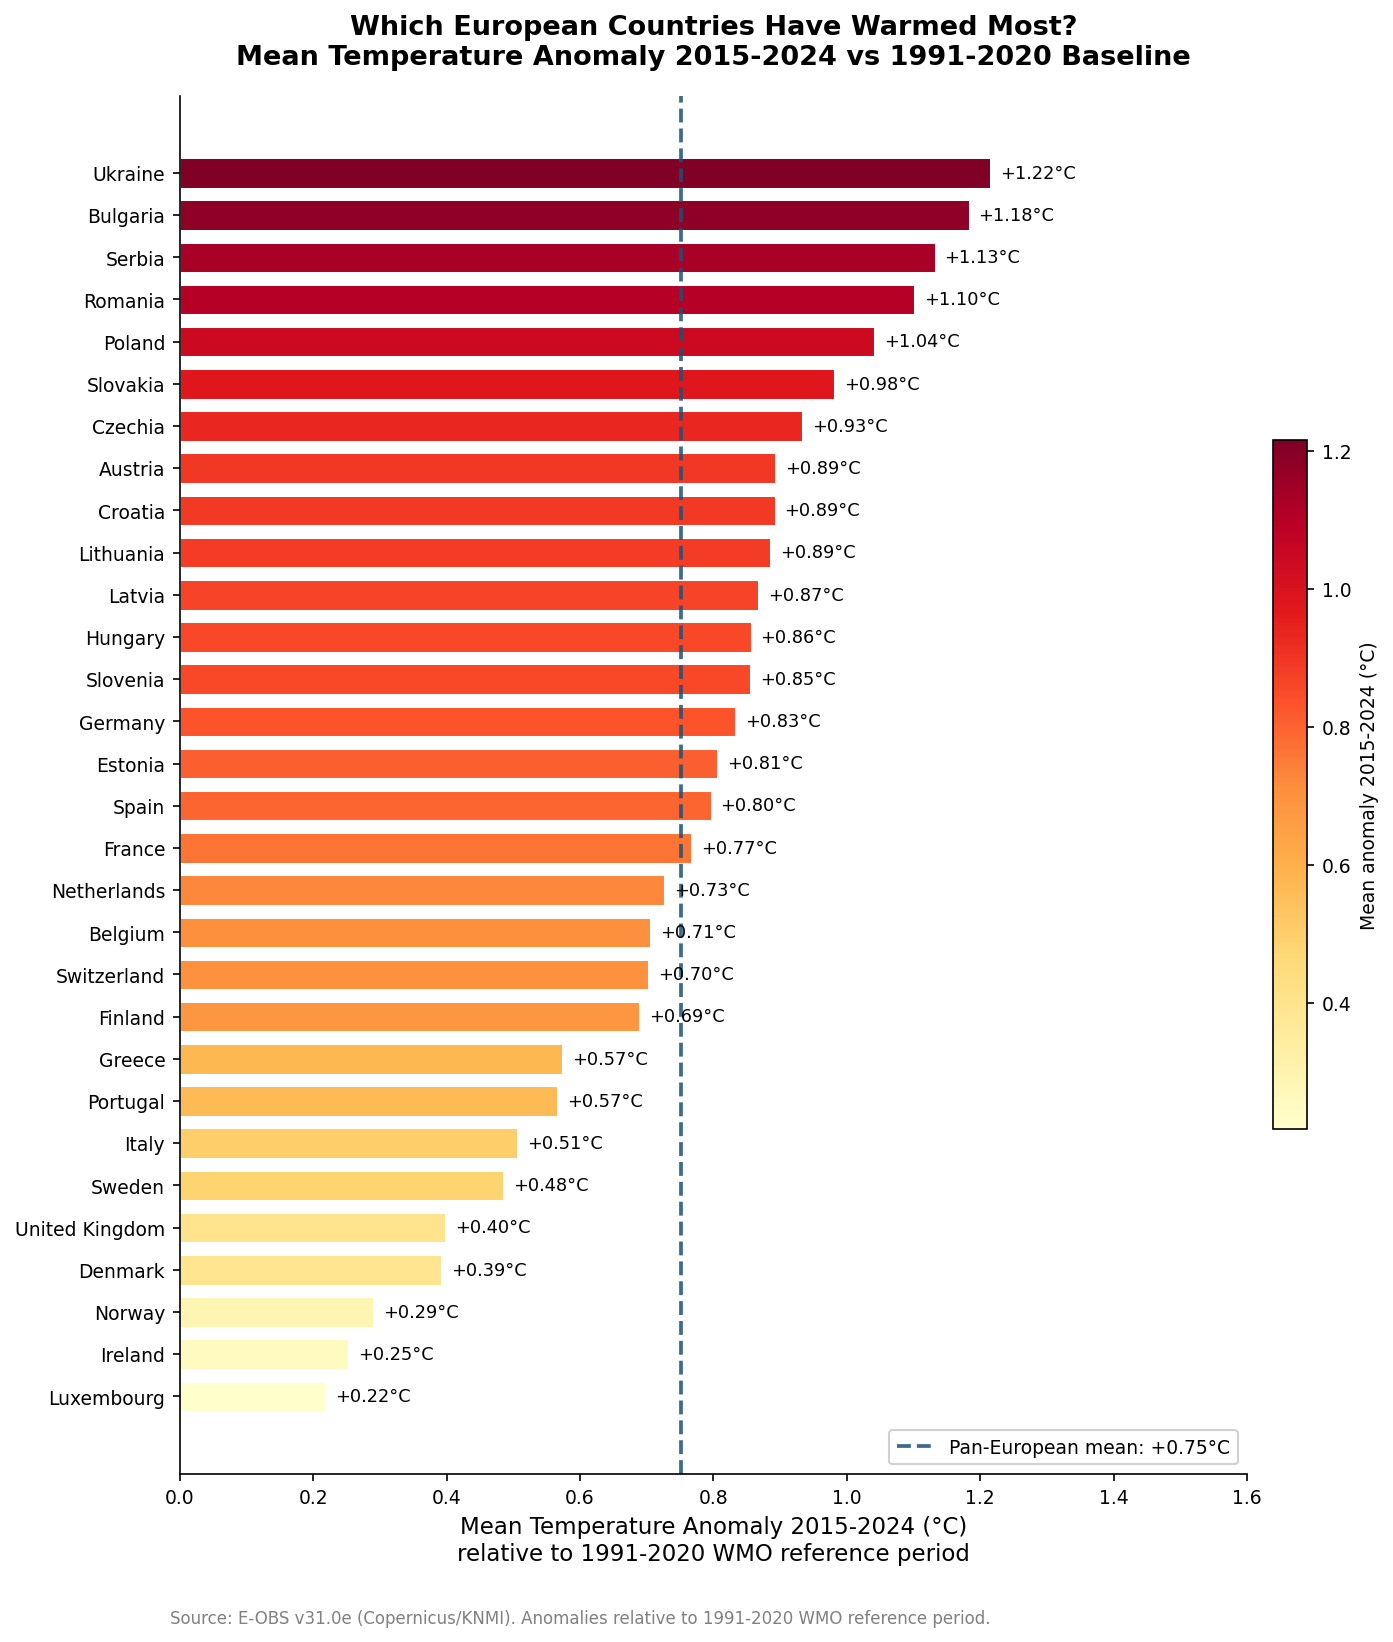

Figure 5 saved to: C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project5\figures\05_recent_decade_anomaly_ranking.png
Pan-European mean anomaly 2015-2024: +0.751 C

Top 5 most anomalous countries 2015-2024:
 country  mean_anomaly_2015_2024
 Ukraine                1.215215
Bulgaria                1.182613
  Serbia                1.131687
 Romania                1.100742
  Poland                1.041294


In [7]:
# -- Compute mean 2015-2024 anomaly per country -------------------------------
recent = tg_anomaly_df[tg_anomaly_df["year"] >= 2015].copy()
recent_mean = (
    recent.groupby("country")["tg_anomaly_c"]
    .mean()
    .reset_index()
    .rename(columns={"tg_anomaly_c": "mean_anomaly_2015_2024"})
)
recent_mean = recent_mean.sort_values("mean_anomaly_2015_2024", ascending=True).reset_index(drop=True)

pan_european_mean = recent_mean["mean_anomaly_2015_2024"].mean()

# -- Colour mapping -----------------------------------------------------------
norm   = plt.Normalize(recent_mean["mean_anomaly_2015_2024"].min(),
                       recent_mean["mean_anomaly_2015_2024"].max())
cmap   = plt.cm.YlOrRd
colors = [cmap(norm(v)) for v in recent_mean["mean_anomaly_2015_2024"]]

fig, ax = plt.subplots(figsize=(10, 11))

# -- Bars ---------------------------------------------------------------------
ax.barh(
    recent_mean["country"],
    recent_mean["mean_anomaly_2015_2024"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

# -- Pan-European mean reference line -----------------------------------------
ax.axvline(
    pan_european_mean,
    color="#1a5276",
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Pan-European mean: +{pan_european_mean:.2f}°C"
)

# -- Value labels -------------------------------------------------------------
for i, (_, row) in enumerate(recent_mean.iterrows()):
    ax.text(
        row["mean_anomaly_2015_2024"] + 0.015,
        i,
        f"+{row['mean_anomaly_2015_2024']:.2f}°C",
        va="center",
        ha="left",
        fontsize=8.5,
        color="black",
    )

# -- Colourbar ----------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Mean anomaly 2015-2024 (°C)", fontsize=9)

# -- Legend -------------------------------------------------------------------
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

# -- Labels and title ---------------------------------------------------------
ax.set_xlabel("Mean Temperature Anomaly 2015-2024 (°C)\nrelative to 1991-2020 WMO reference period",
              fontsize=11)
ax.set_title(
    "Which European Countries Have Warmed Most?\n"
    "Mean Temperature Anomaly 2015-2024 vs 1991-2020 Baseline",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(0, 1.6)

# -- Footnote -----------------------------------------------------------------
fig.text(
    0.12, 0.01,
    "Source: E-OBS v31.0e (Copernicus/KNMI). Anomalies relative to 1991-2020 WMO reference period.",
    fontsize=8, color="grey"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# -- Save ---------------------------------------------------------------------
fig5_path = os.path.join(config.FIGURES_DIR, "05_recent_decade_anomaly_ranking.png")
fig.savefig(fig5_path, dpi=config.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure 5 saved to: {fig5_path}")
print(f"Pan-European mean anomaly 2015-2024: +{pan_european_mean:.3f} C")
print()
print("Top 5 most anomalous countries 2015-2024:")
print(recent_mean.tail(5)[["country", "mean_anomaly_2015_2024"]].iloc[::-1].to_string(index=False))